# 회귀분석 재구성 노트북  
## statsmodels 중심 + Pipeline 기반 스케일링 + 정규화/트리 회귀 비교

이 노트북은 기존 `17_01지도학습_회귀분석_최적회귀_정규화_tree회귀.ipynb`를 다음 기준으로 재구성한 버전입니다.

- **선형모형 해석은 statsmodels 중심**
- **스케일링은 Pipeline으로 처리**
- **변수선택은 statsmodels 기반으로 재구성**
- **정규화 회귀는 Pipeline + sklearn**
- **트리 계열은 스케일링 없이 별도 비교**

> 핵심 원칙  
> - 선형회귀: 해석 중심 → `statsmodels`
> - 정규화 회귀: 예측 최적화 중심 → `sklearn + Pipeline`
> - 트리 회귀: 스케일링 불필요 → 원본 데이터 사용

1. "결국 트리(Tree)로 쓴다"는 게 무슨 뜻인가요?

실무 데이터 분석에서 선형 회귀(Linear Regression)는 데이터가 '직선' 관계일 때만 잘 맞습니다. 하지만 현실 데이터는 매우 복잡하고 삐뚤빼뚤합니다.

선형 회귀의 한계: "공부 시간이 늘면 성적도 직선으로 오른다"라고 가정하지만, 실제로는 어느 시점부터는 효율이 떨어지거나 갑자기 성적이 오르는 구간이 생깁니다.

트리 기반 모델(Decision Tree, XGBoost 등)의 강점: 데이터를 '스무고개' 하듯이 뚝뚝 끊어서 분석합니다. (예: "앱 사용 시간이 10분 이상인가? Yes/No"). 덕분에 비선형적인 복잡한 관계를 훨씬 정확하게 잡아냅니다.

결론: 현업에서 **예측 성능(정확도)** 이 가장 중요할 때는 선형 회귀보다 트리 기반의 모델(Random Forest, XGBoost, LightGBM)을 훨씬 더 많이 쓰기 때문에 그렇게 말씀하신 것입니다.

- 데이터 분석가로서의 한 줄 요약
이 파일은 **"상황에 맞는 도구를 고르는 법"** 을 알려줍니다.

해석과 설명이 중요하다면? → 선형 회귀 + 변수 선택

예측 정확도가 최우선이라면? → 트리 기반 모델 (XGBoost 등)

데이터가 너무 많고 과적합이 걱정된다면? → Lasso / Ridge

강사님 말씀대로 실제 성능은 트리가 좋지만, 분석가는 "왜 이 변수가 중요한지"를 설명해야 할 때가 많으므로 두 가지 모두를 다룰 줄 알아야 합니다. 이 파일의 내용을 이해하면 "이 상황에선 이 모델이 최선입니다"라고 논리적으로 말할 수 있게 됩니다.

1. 이전 파일과의 연결 고리 (관련성 100%)
이 파일은 앞서 배운 선형 회귀의 한계를 극복하는 방법들을 코드로 구현하고 있습니다.

1단계(이전): 기본적인 선형 회귀로 매출을 예측해봄.

2단계(현재 파일): * 변수가 너무 많으면? → **변수 선택(Forward/Backward)** 으로 핵심만 추림.

모델이 너무 복잡해져서 과거 데이터만 잘 맞히면? → **정규화(Lasso, Ridge)** 로 규제함.

데이터가 직선이 아니고 복잡하면? → **트리 모델(XGBoost, LightGBM)** 을 사용함.

2. 강사님이 "결국 트리로 쓴다"고 한 이유 (파일 하단 내용)
이 파일 뒷부분에 XGBoost, LightGBM, CatBoost 같은 모델들이 나오죠? 이게 바로 강사님이 말씀하신 **'트리 기반 부스팅 모델'** 들입니다.

실무에서의 위상: 데이터 분석 대회(캐글 등)나 현업에서 표 형태의 데이터(CSV, DB 데이터)를 다룰 때, 이 모델들은 선형 회귀보다 압도적으로 높은 정확도를 보여줍니다.

파일의 핵심: 선형 회귀부터 시작해서 결국 이 '강력한 트리 모델'들까지 성능을 비교해보고, 최종적으로 어떤 모델이 가장 돈을 잘 벌어다 줄(예측을 잘 할) 모델인지 결정하는 과정을 담고 있습니다.

3. 데이터 분석 직무에서 이 파일의 '진짜' 중요 포인트
실무자라면 이 파일에서 다음 세 가지만은 꼭 기억해야 합니다.

Pipeline (파이프라인): 스케일링, 변수 선택, 모델 학습을 한 번에 묶는 코드입니다. 실무에서 코드를 깔끔하고 실수 없이 관리하는 표준 방식입니다.

하이퍼파라미터 튜닝 (GridSearchCV): 모델의 성능을 극대화하기 위해 '최적의 설정값'을 컴퓨터가 알아서 찾게 만드는 과정입니다. "내가 만든 모델이 최선인가?"라는 질문에 답을 줍니다.

모델 비교 시각화: 마지막 셀에 있는 R2 점수 비교 그래프입니다. 여러 모델을 돌려보고 "우리 데이터에는 이 모델이 가장 적합합니다"라고 보고서에 한 장으로 요약할 수 있는 근거가 됩니다.

요약하자면
이 파일은 **"기초 회귀분석부터 현업 최강 모델(Tree 계열)까지 한 번에 비교하고 최적화하는 전체 프로세스"** 를 담고 있습니다. 데이터 분석가로 취업하시면 가장 많이 반복하게 될 작업 흐름(Workflow)이 바로 이 파일 안에 다 들어있다고 보셔도 무방합니다. 매우 중요한 파일입니다!

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import koreanize_matplotlib
except Exception:
    pass

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy.stats import randint, uniform

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. 데이터 불러오기

In [2]:
url = "https://raw.githubusercontent.com/haram4th/ADsP/main/01%EB%B3%B4%EC%8A%A4%ED%84%B4%EC%A7%91%EA%B0%92%EB%8D%B0%EC%9D%B4%ED%84%B0.csv"
data = pd.read_csv(url)

display(data.head())
print(data.shape)

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격
0,0.0063,18.0000,2.3100,0,0.5380,6.5750,65.2000,4.0900,1,296.0000,15.3000,396.9000,4.9800,24.0000
1,0.0273,0.0000,7.0700,0,0.4690,6.4210,78.9000,4.9671,2,242.0000,17.8000,396.9000,9.1400,21.6000
2,0.0273,0.0000,7.0700,0,0.4690,7.1850,61.1000,4.9671,2,242.0000,17.8000,392.8300,4.0300,34.7000
3,0.0324,0.0000,2.1800,0,0.4580,6.9980,45.8000,6.0622,3,222.0000,18.7000,394.6300,2.9400,33.4000
4,0.0691,0.0000,2.1800,0,0.4580,7.1470,54.2000,6.0622,3,222.0000,18.7000,396.9000,5.3300,36.2000


(506, 14)


## 2. 데이터 확인

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   범죄율           506 non-null    float64
 1   25,000평방피트초과  506 non-null    float64
 2   비소매상업지역비율     506 non-null    float64
 3   찰스강경계         506 non-null    int64  
 4   농축 일산화질소      506 non-null    float64
 5   가구당평균방수       506 non-null    float64
 6   1940년이전건축비율   506 non-null    float64
 7   직업센터접근성       506 non-null    float64
 8   도로접근성         506 non-null    int64  
 9   재산세율          506 non-null    float64
 10  학생/교사비율       506 non-null    float64
 11  흑인비율          506 non-null    float64
 12  하위계층비율        506 non-null    float64
 13  주택가격          506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
범죄율,506.0000,3.6135,8.6015,0.0063,0.0820,0.2565,3.6771,88.9762
"25,000평방피트초과",506.0000,11.3636,23.3225,0.0000,0.0000,0.0000,12.5000,100.0000
비소매상업지역비율,506.0000,11.1368,6.8604,0.4600,5.1900,9.6900,18.1000,27.7400
찰스강경계,506.0000,0.0692,0.2540,0.0000,0.0000,0.0000,0.0000,1.0000
농축 일산화질소,506.0000,0.5547,0.1159,0.3850,0.4490,0.5380,0.6240,0.8710
가구당평균방수,506.0000,6.2846,0.7026,3.5610,5.8855,6.2085,6.6235,8.7800
1940년이전건축비율,506.0000,68.5749,28.1489,2.9000,45.0250,77.5000,94.0750,100.0000
직업센터접근성,506.0000,3.7950,2.1057,1.1296,2.1002,3.2074,5.1884,12.1265
도로접근성,506.0000,9.5494,8.7073,1.0000,4.0000,5.0000,24.0000,24.0000
재산세율,506.0000,408.2372,168.5371,187.0000,279.0000,330.0000,666.0000,711.0000


In [7]:
# column이름에서 특수문자 공백제거
data.columns = [col.replace(",", "_").replace("/", "_").replace(" ", "_") for col in data.columns]
data.columns

Index(['범죄율', '25_000평방피트초과', '비소매상업지역비율', '찰스강경계', '농축_일산화질소', '가구당평균방수',
       '1940년이전건축비율', '직업센터접근성', '도로접근성', '재산세율', '학생_교사비율', '흑인비율', '하위계층비율',
       '주택가격'],
      dtype='object')

In [8]:
target_col = "주택가격"
feature_cols = [c for c in data.columns if c != target_col]

X = data[feature_cols].copy()
y = data[target_col].copy()

print("feature 개수:", X.shape[1])
print("target:", target_col)

feature 개수: 13
target: 주택가격


## 3. 간단한 EDA

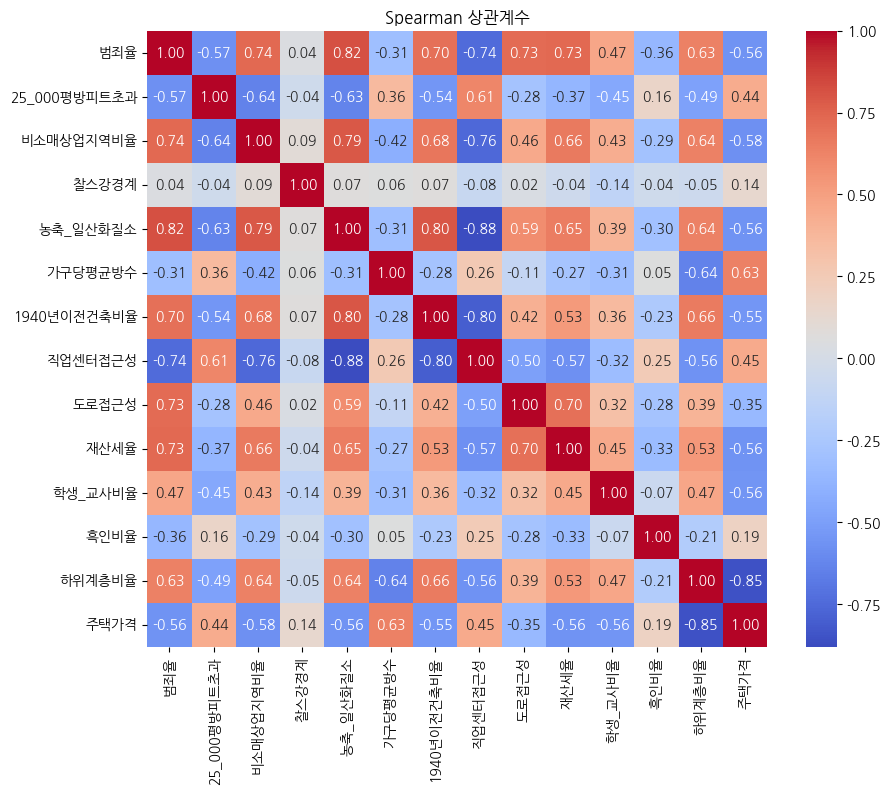

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(method="spearman"), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Spearman 상관계수")
plt.show()

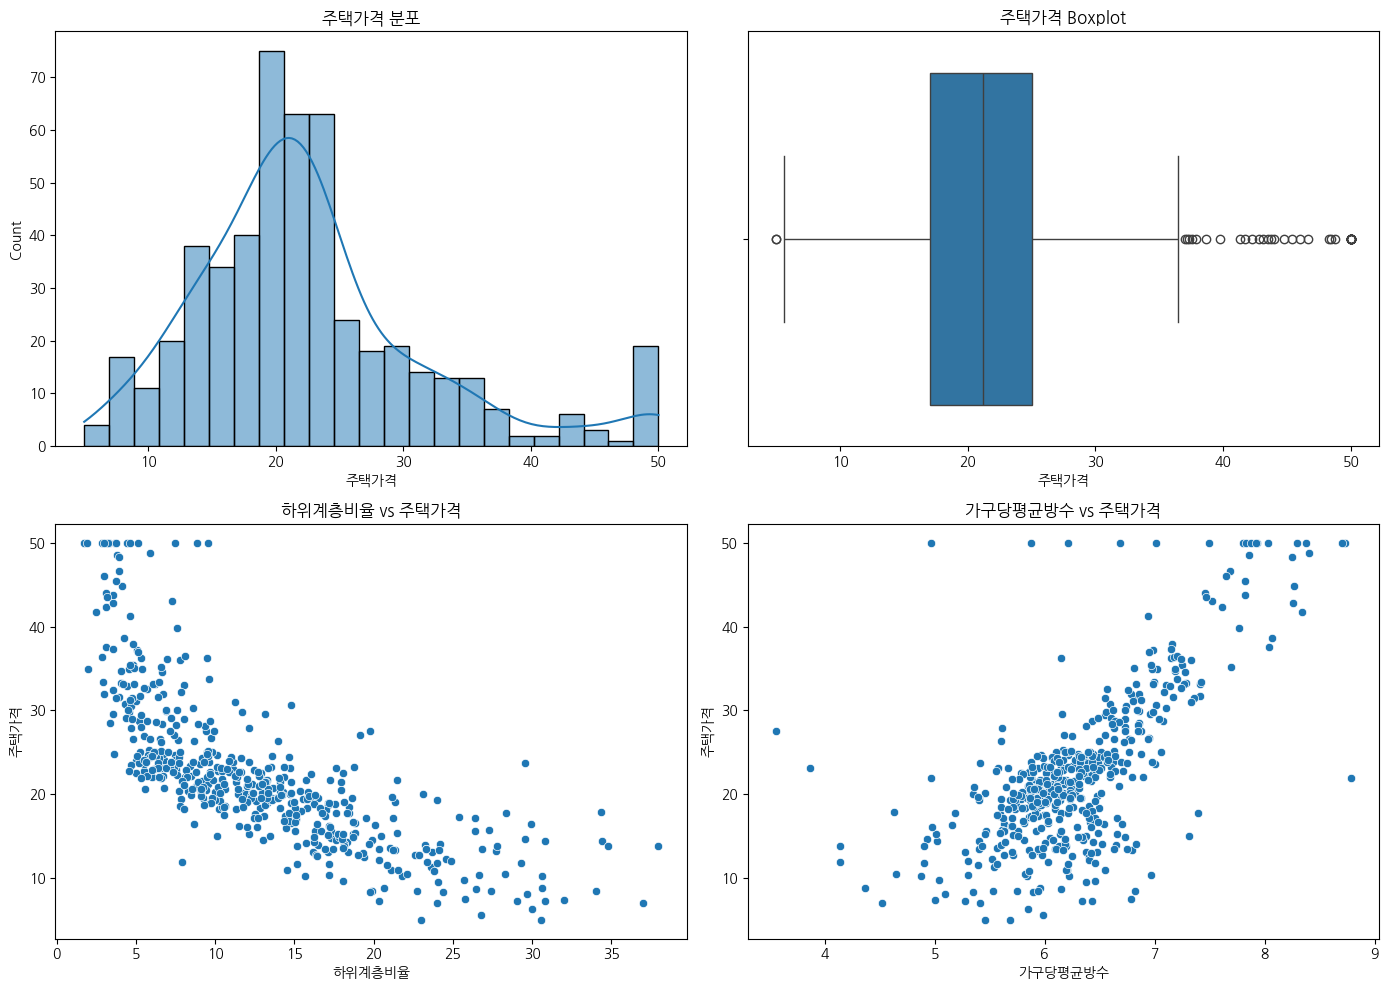

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(data[target_col], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("주택가격 분포")

sns.boxplot(x=data[target_col], ax=axes[0, 1])
axes[0, 1].set_title("주택가격 Boxplot")

sns.scatterplot(data=data, x="하위계층비율", y=target_col, ax=axes[1, 0])
axes[1, 0].set_title("하위계층비율 vs 주택가격")

sns.scatterplot(data=data, x="가구당평균방수", y=target_col, ax=axes[1, 1])
axes[1, 1].set_title("가구당평균방수 vs 주택가격")

plt.tight_layout()
plt.show()

<Axes: >

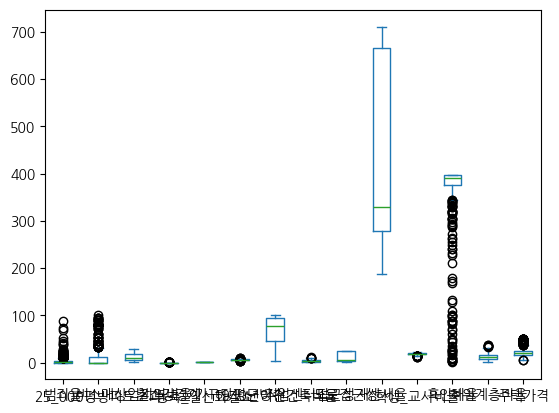

In [13]:
data.plot(kind='box')

## 4. 학습/테스트 분리

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (354, 13)
X_test : (152, 13)


## 5. 스케일링 및 OLS 준비 (절차적 방식)

함수를 만들지 않고 셀에서 순서대로 직접 처리합니다.

In [15]:
# RobustScaler를 Pipeline으로 구성
scale_pipe = Pipeline([
    ("scaler", RobustScaler())
])

# 학습 데이터는 fit_transform, 테스트 데이터는 transform만 적용
X_train_scaled = pd.DataFrame(
    scale_pipe.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scale_pipe.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# statsmodels OLS를 위해 상수항(const) 추가
X_train_const = sm.add_constant(X_train_scaled, has_constant="add")
X_test_const = sm.add_constant(X_test_scaled, has_constant="add")

# OLS 회귀 적합
ols_model = sm.OLS(y_train, X_train_const).fit()

# 테스트 데이터 예측
pred_ols = ols_model.predict(X_test_const)

# 회귀모델 성능평가
# MAE  : 실제값과 예측값 차이의 절대값 평균
#        -> 오차를 직관적으로 해석하기 쉽다
#        -> 값이 작을수록 예측이 좋다
#
# MSE  : 오차를 제곱한 값의 평균
#        -> 큰 오차에 더 큰 패널티를 준다
#        -> 이상치의 영향을 더 크게 반영한다
#        -> 값이 작을수록 좋다
#
# RMSE : MSE에 제곱근을 취한 값
#        -> 원래 타깃 변수와 같은 단위를 가지므로 해석이 쉽다
#        -> 실제 예측 오차 크기를 직관적으로 보기 좋다
#        -> 값이 작을수록 좋다
#
# R2   : 결정계수
#        -> 모델이 종속변수의 변동을 얼마나 설명하는지 나타냄
#        -> 1에 가까울수록 설명력이 좋다
#        -> 0이면 평균으로만 예측한 수준과 비슷
#        -> 음수이면 평균으로 예측하는 것보다도 성능이 나쁨

ols_score = pd.DataFrame({
    "model": ["OLS(statsmodels + Pipeline)"],
    "MAE": [mean_absolute_error(y_test, pred_ols)],
    "MSE": [mean_squared_error(y_test, pred_ols)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, pred_ols))],
    "R2": [r2_score(y_test, pred_ols)]
})

ols_score

,model,MAE,MSE,RMSE,R2
0,OLS(statsmodels + Pipeline),3.1627,21.5174,4.6387,0.7112


## 6. 기본 OLS 회귀 (statsmodels + Pipeline 기반 스케일링)

In [16]:
ols_score

,model,MAE,MSE,RMSE,R2
0,OLS(statsmodels + Pipeline),3.1627,21.5174,4.6387,0.7112


In [17]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   주택가격   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     75.81
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           4.96e-92
Time:                        14:17:54   Log-Likelihood:                -1053.8
No. Observations:                 354   AIC:                             2136.
Df Residuals:                     340   BIC:                             2190.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           23.9494      0.408     58.755   

### 회귀계수 정리

In [18]:
coef_df = pd.DataFrame({
    "coef": ols_model.params,
    "p_value": ols_model.pvalues,
    "abs_coef": ols_model.params.abs()
}).sort_values("abs_coef", ascending=False)

coef_df

,coef,p_value,abs_coef
const,23.9494,0.0000,23.9494
하위계층비율,-5.1223,0.0000,5.1223
도로접근성,4.8545,0.0033,4.8545
직업센터접근성,-4.6112,0.0000,4.6112
재산세율,-3.3678,0.0602,3.3678
학생_교사비율,-3.2329,0.0000,3.2329
가구당평균방수,3.2143,0.0000,3.2143
찰스강경계,3.1198,0.0028,3.1198
농축_일산화질소,-2.7905,0.0013,2.7905
25_000평방피트초과,0.7162,0.0433,0.7162


## 7. 잔차 진단

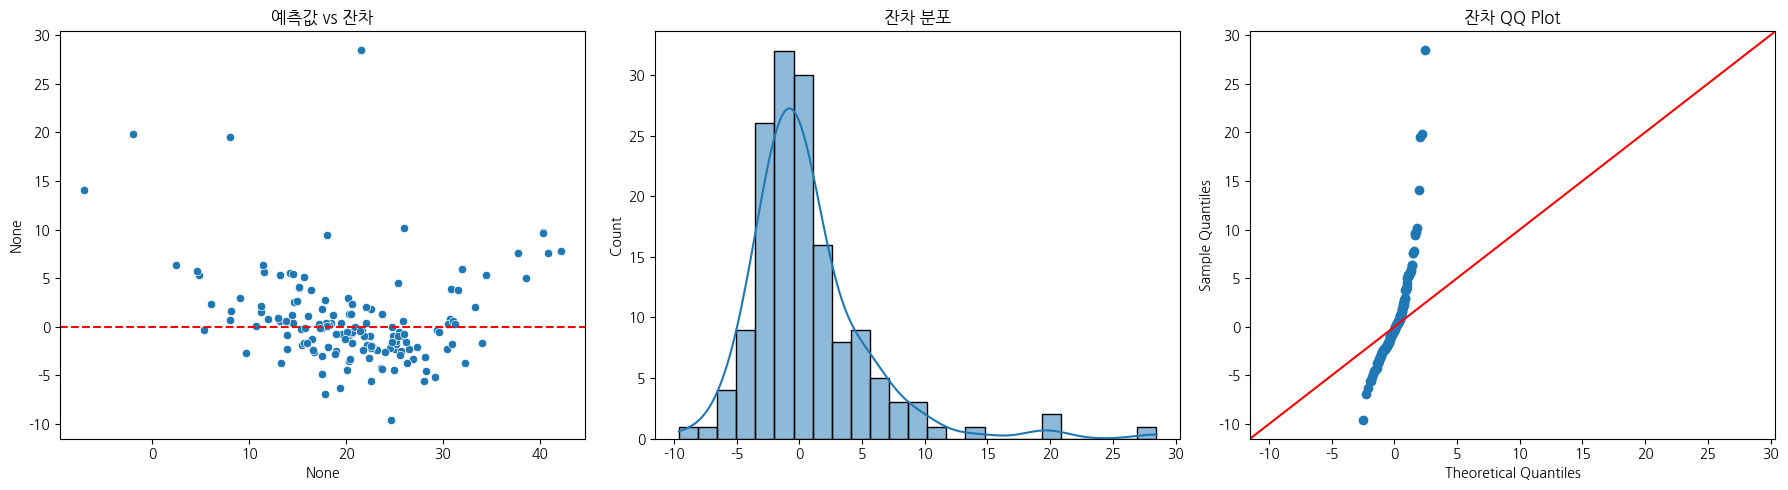

In [82]:
# OLS 잔차 계산
# 잔차(residual) = 실제값 - 예측값
# 즉, 모델이 얼마나 틀렸는지를 나타내는 값
# 잔차가 0에 가까울수록 예측이 잘 된 것
residuals = y_test - pred_ols

# 잔차 진단 그래프
# 회귀분석에서는 단순히 R2만 보는 것이 아니라
# 잔차를 통해 선형회귀의 가정이 잘 만족되는지도 함께 확인해야 함
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 예측값 vs 잔차 그래프
# 목적:
# - 선형성 확인
# - 등분산성 확인
#
# 해석:
# - 이상적이면 잔차가 0을 중심으로 랜덤하게 퍼져야 함
# - 곡선 패턴이 보이면 선형성 문제가 있을 수 있음
# - 부채꼴 모양이면 등분산성 문제가 있을 수 있음
# - 특정 몇 개 점이 멀리 떨어져 있으면 이상치 가능성이 있음
sns.scatterplot(x=pred_ols, y=residuals, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")  # 잔차=0 기준선
axes[0].set_title("예측값 vs 잔차")

# 2. 잔차 분포 히스토그램
# 목적:
# - 잔차가 정규분포에 가까운지 확인
#
# 해석:
# - 이상적이면 0을 중심으로 좌우대칭인 종 모양이면 좋음
# - 한쪽으로 치우치면 왜도(skewness)가 존재할 수 있음
# - 꼬리가 너무 두꺼우면 극단값(outlier)의 영향이 있을 수 있음
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("잔차 분포")

# 3. QQ Plot
# 목적:
# - 잔차의 정규성을 더 구체적으로 확인
#
# 해석:
# - 점들이 대각선(45도 직선) 위에 가깝게 놓이면 정규성이 잘 만족됨
# - 양쪽 끝이 크게 벗어나면 꼬리 부분에서 정규성이 약할 수 있음
# - 일부 점이 멀리 벗어나면 이상치 가능성이 있음
sm.qqplot(residuals, line="45", ax=axes[2])
axes[2].set_title("잔차 QQ Plot")

# 그래프 간격 자동 조정 후 출력
plt.tight_layout()
plt.show()

# 잔차진단 핵심 해석
# 1) 예측값 vs 잔차 : 선형성, 등분산성 확인
# 2) 잔차 분포      : 잔차의 대략적인 정규성 확인
# 3) QQ Plot        : 잔차 정규성을 더 정밀하게 확인
#
# 좋은 회귀모델이라면
# - 잔차가 0을 중심으로 랜덤하게 퍼지고
# - 잔차 분포가 대체로 정규분포에 가깝고
# - QQ Plot 점들이 직선 부근에 위치해야 함

### 다중공선성 확인 (VIF)


### 의미
한 독립변수가 **다른 모든 독립변수로 설명되는 정도**

$
VIF = \frac{1}{1-R^2}
$

여기서

- ${R^2}$ = 해당 변수를 나머지 변수로 회귀했을 때의 결정계수

즉

> 특정 변수 하나가 다른 변수들의 **선형결합으로 설명되는 정도**

VIF 해석 기준

VIF = 1      → 다른 변수와 상관 없음  
VIF < 5      → 다중공선성 문제 거의 없음  
5 ≤ VIF <10  → 다중공선성 의심  
VIF ≥ 10     → 다중공선성 심각 (변수 제거 고려)  

In [19]:
# VIF (Variance Inflation Factor) 계산
# VIF는 독립변수들 사이의 다중공선성(multicollinearity)을 확인하는 지표
# 다중공선성이 높으면 회귀계수가 불안정해지고 해석이 어려워질 수 있음

vif_df = pd.DataFrame({
    
    # 독립변수 이름
    "feature": X_train_const.columns,
    
    # 각 변수의 VIF 계산
    # variance_inflation_factor()는
    # 특정 변수를 나머지 변수들로 회귀했을 때의 R²을 이용하여 계산됨
    # VIF = 1 / (1 - R²)
    "VIF": [
        variance_inflation_factor(X_train_const.values, i)
        for i in range(X_train_const.shape[1])
    ]

# VIF 값이 큰 순서로 정렬 (다중공선성이 높은 변수 확인)
}).sort_values("VIF", ascending=False)

# 결과 출력
vif_df

,feature,VIF
10,재산세율,8.8795
9,도로접근성,7.5347
5,농축_일산화질소,4.6272
8,직업센터접근성,3.9710
3,비소매상업지역비율,3.8365
7,1940년이전건축비율,2.9961
13,하위계층비율,2.6793
0,const,2.5056
2,25_000평방피트초과,2.3945
6,가구당평균방수,1.9131


# 변수가 너무 많거나 모델이 복잡해질 때 어떻게 관리할 것인가?

### ① 변수 선택법 (Forward/Backward Selection)
내용: 수많은 데이터 중 진짜 의미 있는 것만 골라내는 기술입니다.

왜 중요하나: 앞서 보신 '웹사이트 사용 시간'처럼 쓸모없는 변수가 많으면 모델이 멍청해집니다. 효율적인 변수만 남겨 모델을 가볍고 강력하게 만드는 과정입니다.

### ② 정규화 회귀 (Lasso, Ridge, Elastic Net)
내용: 회귀 계수(숫자)가 너무 커지지 않도록 '벌칙'을 주는 것입니다.

왜 중요하나: 모델이 학습 데이터에만 너무 과하게 집착하는 **'과적합(Overfitting)'** 을 방지합니다. 실무에서는 "과거 데이터는 100점인데 새 데이터는 50점"인 상황을 막는 것이 가장 큰 숙제인데, 이때 이 기법들이 필수입니다.

Lasso: 중요하지 않은 변수의 영향력을 아예 0으로 만들어 버림 (변수 선택 효과)

Ridge: 변수의 영향력을 골고루 줄여서 안정적으로 만듦

### ③ 트리 기반 회귀 (Tree-based Regression)
내용: 데이터를 쪼개서 평균값을 내는 방식입니다.

왜 중요하나: 선형 회귀처럼 복잡한 통계적 가정(정규성, 등분산성 등)을 지키지 않아도 되고, 데이터에 이상치(Outlier)가 섞여 있어도 아주 강건하게 잘 작동합니다.

# 1) 변수 선택법
## 변수 선택법의 종류와 목적

변수 선택(variable selection)의 목적은  
**예측에 꼭 필요한 변수만 남겨서 모델을 단순하게 만들고**,  
동시에 **과적합을 줄이며 해석력을 높이는 것**입니다.

즉, 변수 선택은 다음을 위해 수행합니다.

- 불필요한 변수 제거
- 모델 단순화
- 과적합 방지
- 해석 용이성 향상
- 예측 성능 개선



## 변수 선택법의 대표적인 종류

### 1. 전진 선택법 (Forward Selection)
변수가 없는 상태에서 시작하여  
가장 중요한 변수부터 **하나씩 추가**하는 방법입니다.

- 시작: 변수 0개
- 과정: 성능이 가장 좋아지는 변수 추가
- 장점: 계산량이 비교적 적음
- 단점: 초기에 잘못 들어간 변수를 나중에 제거하기 어려움



### 2. 후진 제거법 (Backward Elimination)
모든 변수를 넣고 시작한 뒤  
중요하지 않은 변수를 **하나씩 제거**하는 방법입니다.

- 시작: 모든 변수 포함
- 과정: 가장 덜 중요한 변수 제거
- 장점: 전체 변수 기준으로 시작하므로 안정적일 수 있음
- 단점: 변수 수가 많으면 계산량이 큼



### 3. 단계적 선택법 (Stepwise Selection)
전진 선택과 후진 제거를 결합한 방법입니다.

- 변수를 추가하기도 하고
- 이미 들어간 변수를 다시 제거하기도 함

즉, 더 유연한 선택 방법입니다.



### 4. 전체 부분집합 선택법 (Best Subset Selection)
가능한 모든 변수 조합을 비교해서  
가장 좋은 모델을 선택하는 방법입니다.

- 가장 정확한 방법 중 하나
- 하지만 변수 수가 많아지면 계산량이 매우 커짐





## 변수 선택 시 사용하는 기준

변수 선택에서는 단순히 설명력이 높은 모델보다  
**설명력과 복잡도를 함께 고려한 모델**을 선택하는 것이 중요합니다.

대표적인 기준이 다음과 같습니다.

- AIC
- BIC
- Mallows' Cp

이 지표들은  
**모델 적합도는 높이고, 변수 수가 너무 많아지는 것은 벌점(penalty)** 으로 제어합니다.



## 1. AIC (Akaike Information Criterion)

AIC는 모델의 적합도와 복잡도를 함께 고려하는 기준입니다.  
모댈의 성능지표로서 `MSE에 변수 수만큼 페널티`를 주는 지표. 

공식:

$$
AIC = -2 \log L + 2k
$$

- \(L\): 가능도(likelihood)
- \(k\): 모형의 모수 개수

### 의미
- 모델이 데이터를 잘 설명할수록 좋음
- 하지만 변수가 많아질수록 벌점을 줌

### 해석
- **AIC 값이 작을수록 좋은 모델**
- 예측 성능 중심의 기준으로 많이 사용됨



## 2. BIC (Bayesian Information Criterion)

BIC는 AIC와 마찬가지로 **모델의 적합도와 복잡도를 함께 고려하여 모델을 선택하는 기준**입니다.  
즉, 모델이 데이터를 얼마나 잘 설명하는지와 함께 **변수의 개수가 너무 많아지는 것을 벌점(penalty)** 으로 조정합니다.

AIC는 모델 선택에 널리 사용되는 지표이지만, **표본의 크기가 커질수록 다소 부정확해질 수 있다는 단점**이 있습니다. 이러한 단점을 보완하기 위해 제안된 지표가 **BIC**입니다.

BIC는 AIC와 구조는 비슷하지만 **표본 크기(n)를 고려하여 벌점이 더 크게 적용되는 특징**이 있습니다.  
따라서 **표본의 수가 많아질수록 AIC보다 더 엄격하게 모델의 복잡도를 평가**합니다.

이 때문에 BIC는 **변수의 개수가 많은 복잡한 모델보다 변수 수가 적은 단순한 모델을 선택하는 경향**이 있습니다.

공식:

$$
BIC = -2 \log L + k \log n
$$

- \(n\): 표본 수
- \(k\): 모수 개수

### 의미
- 변수 수가 많아질수록 벌점을 줌
- AIC보다 벌점이 더 큼

### 해석
- **BIC 값이 작을수록 좋은 모델**
- AIC보다 더 단순한 모델을 선택하는 경향이 있음



## 3. Mallows' Cp (멜로우 Cp)

Mallows' Cp는  
선택된 변수 모형이 전체 모형에 비해 얼마나 적절한지를 평가하는 지표입니다.

### 의미
- 변수 개수가 너무 적으면 설명력이 부족할 수 있고
- 변수 개수가 너무 많으면 불필요하게 복잡해질 수 있음

Cp는 이런 균형을 보기 위한 기준입니다.

### 해석
- **Cp 값이 작을수록 좋음**
- 보통 **Cp가 변수 개수 p와 비슷하면 좋은 모델**로 해석함

즉,

$$
Cp \approx p
$$

이면 적절한 변수 선택이 되었다고 봅니다.



## AIC, BIC, Mallows' Cp 비교

| 지표 | 목적 | 특징 | 선택 기준 |
|---|---|---|---|
| AIC | 적합도 + 복잡도 고려 | 예측 성능 중시 | 작을수록 좋음 |
| BIC | 적합도 + 복잡도 고려 | AIC보다 벌점이 큼, 더 단순한 모델 선호 | 작을수록 좋음 |
| Mallows' Cp | 전체모형 대비 부분모형 평가 | 변수 수와 설명력의 균형 확인 | 작고, Cp가 p와 비슷할수록 좋음 |



## 한 줄 정리

- **AIC**: 예측력을 고려한 모델 선택 기준
- **BIC**: 더 강한 벌점으로 단순한 모델을 선호하는 기준
- **Mallows' Cp**: 변수 수와 설명력의 균형이 적절한지 보는 기준

## 8. 최적 회귀 방정식 - 변수선택: scikit-learn 기반 후진선택

이제부터는 **statsmodels 방식 대신 scikit-learn 방식**으로 진행합니다.  
후진선택은 `SequentialFeatureSelector(direction="backward")`와 `Pipeline`을 사용하고,  
특성 개수별 교차검증 점수를 직접 비교한 뒤 최적 개수를 선택합니다.

In [23]:
len(X_train.columns)

13

In [20]:
cv_5 = KFold(n_splits=5, shuffle=True, random_state=42)
feature_names = X_train.columns.tolist()

bw_cv_result = []

for n_features in range(1, X_train.shape[1]):
    backward_pipe_step = Pipeline([
        ("scaler", RobustScaler()),
        ("sfs", SequentialFeatureSelector(
            LinearRegression(),
            n_features_to_select=n_features,
            direction="backward",
            scoring="neg_mean_squared_error",
            cv=cv_5,
            n_jobs=-1
        )),
        ("model", LinearRegression())
    ])

    bw_cv_score = cross_val_score(
        backward_pipe_step,
        X_train,
        y_train,
        cv=cv_5,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    ).mean()

    bw_cv_result.append({
        "n_features": n_features,
        "cv_neg_mse": bw_cv_score,
        "cv_rmse": np.sqrt(-bw_cv_score)
    })

bw_cv_result_df = pd.DataFrame(bw_cv_result).sort_values("cv_neg_mse", ascending=False)
bw_best_n = int(bw_cv_result_df.iloc[0]["n_features"])

backward_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("sfs", SequentialFeatureSelector(
        LinearRegression(),
        n_features_to_select=bw_best_n,
        direction="backward",
        scoring="neg_mean_squared_error",
        cv=cv_5,
        n_jobs=-1
    )),
    ("model", LinearRegression())
])

backward_pipe.fit(X_train, y_train)
bw_pred = backward_pipe.predict(X_test)

bw_support = backward_pipe.named_steps["sfs"].get_support()
selected_bw = X_train.columns[bw_support].tolist()

bw_score = pd.DataFrame({
    "model": [f"Backward SFS + LinearRegression ({bw_best_n}개 변수)"],
    "MAE": [mean_absolute_error(y_test, bw_pred)],
    "MSE": [mean_squared_error(y_test, bw_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, bw_pred))],
    "R2": [r2_score(y_test, bw_pred)]
})

print("최적 변수 개수:", bw_best_n)
print("선택된 변수:")
print(selected_bw)

최적 변수 개수: 12
선택된 변수:
['범죄율', '25_000평방피트초과', '찰스강경계', '농축_일산화질소', '가구당평균방수', '1940년이전건축비율', '직업센터접근성', '도로접근성', '재산세율', '학생_교사비율', '흑인비율', '하위계층비율']


In [24]:
bw_cv_result_df

,n_features,cv_neg_mse,cv_rmse
11,12,-26.9105,5.1875
9,10,-26.9711,5.1934
10,11,-26.9979,5.1959
8,9,-27.6276,5.2562
7,8,-27.9191,5.2839
6,7,-28.4543,5.3343
4,5,-28.5808,5.3461
5,6,-28.6298,5.3507
2,3,-29.3023,5.4132
3,4,-30.5822,5.5301


In [25]:
bw_score

,model,MAE,MSE,RMSE,R2
0,Backward SFS + LinearRegression (12개 변수),3.1442,21.4292,4.6292,0.7124


In [26]:
pd.Series(selected_bw, name='selected_feature')

0              범죄율
1     25_000평방피트초과
2            찰스강경계
3         농축_일산화질소
4          가구당평균방수
5      1940년이전건축비율
6          직업센터접근성
7            도로접근성
8             재산세율
9          학생_교사비율
10            흑인비율
11          하위계층비율
Name: selected_feature, dtype: object

## 9. 변수선택: scikit-learn 기반 전진선택

전진선택도 `SequentialFeatureSelector(direction="forward")`로 진행합니다.  
후진선택과 동일하게 **특성 개수별 교차검증 성능**을 비교해서 최적 개수를 선택합니다.

In [27]:
fw_cv_result = []

for n_features in range(1, X_train.shape[1]):
    forward_pipe_step = Pipeline([
        ("scaler", RobustScaler()),
        ("sfs", SequentialFeatureSelector(
            LinearRegression(),
            n_features_to_select=n_features,
            direction="forward",
            scoring="neg_mean_squared_error",
            cv=cv_5,
            n_jobs=-1
        )),
        ("model", LinearRegression())
    ])

    fw_cv_score = cross_val_score(
        forward_pipe_step,
        X_train,
        y_train,
        cv=cv_5,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    ).mean()

    fw_cv_result.append({
        "n_features": n_features,
        "cv_neg_mse": fw_cv_score,
        "cv_rmse": np.sqrt(-fw_cv_score)
    })

fw_cv_result_df = pd.DataFrame(fw_cv_result).sort_values("cv_neg_mse", ascending=False)
fw_best_n = int(fw_cv_result_df.iloc[0]["n_features"])

forward_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("sfs", SequentialFeatureSelector(
        LinearRegression(),
        n_features_to_select=fw_best_n,
        direction="forward",
        scoring="neg_mean_squared_error",
        cv=cv_5,
        n_jobs=-1
    )),
    ("model", LinearRegression())
])

forward_pipe.fit(X_train, y_train)
fw_pred = forward_pipe.predict(X_test)

fw_support = forward_pipe.named_steps["sfs"].get_support()
selected_fw = X_train.columns[fw_support].tolist()

fw_score = pd.DataFrame({
    "model": [f"Forward SFS + LinearRegression ({fw_best_n}개 변수)"],
    "MAE": [mean_absolute_error(y_test, fw_pred)],
    "MSE": [mean_squared_error(y_test, fw_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, fw_pred))],
    "R2": [r2_score(y_test, fw_pred)]
})

print("최적 변수 개수:", fw_best_n)
print("선택된 변수:")
print(selected_fw)

최적 변수 개수: 10
선택된 변수:
['범죄율', '25_000평방피트초과', '찰스강경계', '농축_일산화질소', '가구당평균방수', '직업센터접근성', '도로접근성', '학생_교사비율', '흑인비율', '하위계층비율']


In [28]:
fw_cv_result_df

,n_features,cv_neg_mse,cv_rmse
9,10,-26.4854,5.1464
11,12,-26.5798,5.1556
10,11,-26.6749,5.1648
8,9,-27.5108,5.2451
5,6,-28.2514,5.3152
6,7,-28.3086,5.3206
7,8,-28.4117,5.3303
4,5,-28.7202,5.3591
2,3,-29.3023,5.4132
3,4,-30.7848,5.5484


In [29]:
fw_score

,model,MAE,MSE,RMSE,R2
0,Forward SFS + LinearRegression (10개 변수),3.2198,22.3407,4.7266,0.7002


In [30]:
pd.Series(selected_fw, name='selected_feature')

0             범죄율
1    25_000평방피트초과
2           찰스강경계
3        농축_일산화질소
4         가구당평균방수
5         직업센터접근성
6           도로접근성
7         학생_교사비율
8            흑인비율
9          하위계층비율
Name: selected_feature, dtype: object

# 2) 정규화 회귀 (Regularized Regression)

정규화 회귀는 **회귀모형에서 변수의 계수(coefficient)가 너무 커지는 것을 방지하기 위해 규제(패널티)를 추가하는 방법**입니다.  
이를 통해 **과적합(overfitting)을 줄이고 모델의 일반화 성능을 높일 수 있습니다.**

기본적인 선형회귀는 다음과 같이 **오차의 제곱합을 최소화**합니다.

$$
\min \sum (y_i - \hat{y}_i)^2
$$

하지만 정규화 회귀에서는 **계수의 크기에 대한 패널티를 추가**합니다.

$$
\min \left( \sum (y_i - \hat{y}_i)^2 + \text{Penalty} \right)
$$

대표적인 정규화 방법은 다음 세 가지입니다.

- L1 규제 (Lasso)
- L2 규제 (Ridge)
- Elastic Net



## 1️⃣ L1 규제 (Lasso Regression)

L1 규제는 **회귀계수의 절대값 합을 패널티로 사용하는 방법**입니다.

$$
\sum | \beta_j |
$$

### 특징

- 일부 변수의 계수를 **0으로 만들어 변수 선택 효과**가 있음
- 모델을 **자동으로 단순화**할 수 있음
- 중요한 변수만 남기는 데 유리

### 요약

> **불필요한 변수를 제거하는 데 효과적인 규제 방법**



## 2️⃣ L2 규제 (Ridge Regression)

L2 규제는 **회귀계수의 제곱합을 패널티로 사용하는 방법**입니다.

$$
\sum \beta_j^2
$$

### 특징

- 계수를 **0에 가깝게 줄이지만 완전히 제거하지는 않음**
- 모든 변수를 **조금씩 사용하는 모델**
- **다중공선성(multicollinearity)** 문제 완화에 효과적

### 요약

> **계수 크기를 안정적으로 줄여 모델을 안정화하는 방법**



## 3️⃣ Elastic Net

Elastic Net은 **L1 규제와 L2 규제를 동시에 사용하는 방법**입니다.

$$
\lambda_1 \sum |\beta_j| + \lambda_2 \sum \beta_j^2
$$

### 특징

- L1의 **변수 선택 기능**
- L2의 **안정적인 계수 축소**
- 두 규제의 장점을 결합

### 요약

> **변수 선택과 모델 안정성을 동시에 고려하는 방법**



## L1, L2, Elastic Net 비교

| 방법 | 패널티 방식 | 변수 제거 | 특징 |
|---|:---:|---|---|
| L1 (Lasso) | $\beta$ | 가능 | 자동 변수 선택 |
| L2 (Ridge) | $\beta^2$ | 불가능 | 계수 안정화 |
| Elastic Net | L1 + L2 | 가능 | 두 방법의 장점 결합 |



## 한 줄 정리

- **L1 (Lasso)** → 중요하지 않은 변수를 **0으로 만들어 제거**
- **L2 (Ridge)** → 모든 계수를 **작게 만들어 모델 안정화**
- **Elastic Net** → **변수 선택 + 안정성**을 동시에 고려

## 10. scikit-learn 정규화 회귀

정규화 회귀도 모두 **Pipeline + scikit-learn** 조합으로 진행합니다.  
여기서는 `LassoCV`, `RidgeCV`, `ElasticNetCV`를 사용해 최적 규제 강도를 자동으로 탐색합니다.

In [31]:
lasso_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LassoCV(cv=cv_5, random_state=42, max_iter=100000))
])

ridge_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 100), cv=cv_5))
])

elastic_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        cv=cv_5,
        random_state=42,
        max_iter=100000
    ))
])

lasso_pipe.fit(X_train, y_train)
ridge_pipe.fit(X_train, y_train)
elastic_pipe.fit(X_train, y_train)

lasso_pred = lasso_pipe.predict(X_test)
ridge_pred = ridge_pipe.predict(X_test)
elastic_pred = elastic_pipe.predict(X_test)

sk_reg_scores = pd.DataFrame([
    {
        "model": "LassoCV(Pipeline)",
        "MAE": mean_absolute_error(y_test, lasso_pred),
        "MSE": mean_squared_error(y_test, lasso_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, lasso_pred)),
        "R2": r2_score(y_test, lasso_pred)
    },
    {
        "model": "RidgeCV(Pipeline)",
        "MAE": mean_absolute_error(y_test, ridge_pred),
        "MSE": mean_squared_error(y_test, ridge_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, ridge_pred)),
        "R2": r2_score(y_test, ridge_pred)
    },
    {
        "model": "ElasticNetCV(Pipeline)",
        "MAE": mean_absolute_error(y_test, elastic_pred),
        "MSE": mean_squared_error(y_test, elastic_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, elastic_pred)),
        "R2": r2_score(y_test, elastic_pred)
    }
])

lasso_coef = pd.Series(lasso_pipe.named_steps["model"].coef_, index=X_train.columns, name="Lasso_coef")
ridge_coef = pd.Series(ridge_pipe.named_steps["model"].coef_, index=X_train.columns, name="Ridge_coef")
elastic_coef = pd.Series(elastic_pipe.named_steps["model"].coef_, index=X_train.columns, name="Elastic_coef")

sk_reg_scores

,model,MAE,MSE,RMSE,R2
0,LassoCV(Pipeline),3.1664,21.7684,4.6657,0.7079
1,RidgeCV(Pipeline),3.1815,22.0446,4.6952,0.7042
2,ElasticNetCV(Pipeline),3.1717,21.8754,4.6771,0.7064


In [32]:
print("Lasso best alpha         :", lasso_pipe.named_steps["model"].alpha_)
print("Ridge best alpha         :", ridge_pipe.named_steps["model"].alpha_)
print("ElasticNet best alpha    :", elastic_pipe.named_steps["model"].alpha_)
print("ElasticNet best l1_ratio :", elastic_pipe.named_steps["model"].l1_ratio_)

Lasso best alpha         : 0.013639838211744403
Ridge best alpha         : 3.2745491628777286
ElasticNet best alpha    : 0.015155375790827114
ElasticNet best l1_ratio : 0.9


In [33]:
display(lasso_coef.sort_values(key=np.abs, ascending=False).to_frame().head(10))
display(ridge_coef.sort_values(key=np.abs, ascending=False).to_frame().head(10))
display(elastic_coef.sort_values(key=np.abs, ascending=False).to_frame().head(10))

,Lasso_coef
하위계층비율,-5.1251
직업센터접근성,-4.3953
도로접근성,3.6972
가구당평균방수,3.2382
학생_교사비율,-3.1527
찰스강경계,3.0376
농축_일산화질소,-2.5441
재산세율,-2.1407
25_000평방피트초과,0.6252
1940년이전건축비율,-0.4311


,Ridge_coef
하위계층비율,-5.0113
직업센터접근성,-4.1652
가구당평균방수,3.3187
도로접근성,3.0698
학생_교사비율,-3.0680
찰스강경계,2.9159
농축_일산화질소,-2.3444
재산세율,-1.7223
25_000평방피트초과,0.5918
1940년이전건축비율,-0.5260


,Elastic_coef
하위계층비율,-5.1054
직업센터접근성,-4.3182
도로접근성,3.3782
가구당평균방수,3.2576
학생_교사비율,-3.1245
찰스강경계,3.0045
농축_일산화질소,-2.4676
재산세율,-1.8474
25_000평방피트초과,0.6028
1940년이전건축비율,-0.4363


## 11. GridSearchCV / RandomizedSearchCV 추가 비교

이번에는 **탐색 기반 하이퍼파라미터 튜닝**도 추가합니다.  
- 선형계열: `GridSearchCV`로 Ridge / ElasticNet 탐색  
- 트리계열: `GridSearchCV`, `RandomizedSearchCV`로 주요 파라미터 탐색  

이렇게 하면 `CV 내장 모델(LassoCV 등)`과 `탐색 기반 튜닝(Grid/Random Search)` 결과를 함께 비교할 수 있습니다.

In [34]:
ridge_grid = GridSearchCV(
    estimator=Pipeline([
        ("scaler", RobustScaler()),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 100), cv=cv_5))
    ]),
    param_grid={
        "model__alphas": [
            np.logspace(-3, 1, 30),
            np.logspace(-2, 2, 40),
            np.logspace(-1, 3, 50)
        ]
    },
    scoring="neg_mean_squared_error",
    cv=cv_5,
    n_jobs=-1
)

elastic_grid = GridSearchCV(
    estimator=Pipeline([
        ("scaler", RobustScaler()),
        ("model", ElasticNetCV(cv=cv_5, random_state=42, max_iter=100000))
    ]),
    param_grid={
        "model__l1_ratio": [[0.1, 0.3, 0.5, 0.7, 0.9], [0.2, 0.4, 0.6, 0.8, 1.0]],
        "model__n_alphas": [100, 200]
    },
    scoring="neg_mean_squared_error",
    cv=cv_5,
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)
elastic_grid.fit(X_train, y_train)

ridge_grid_pred = ridge_grid.predict(X_test)
elastic_grid_pred = elastic_grid.predict(X_test)

search_linear_scores = pd.DataFrame([
    {
        "model": "GridSearch RidgeCV Pipeline",
        "MAE": mean_absolute_error(y_test, ridge_grid_pred),
        "MSE": mean_squared_error(y_test, ridge_grid_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, ridge_grid_pred)),
        "R2": r2_score(y_test, ridge_grid_pred)
    },
    {
        "model": "GridSearch ElasticNetCV Pipeline",
        "MAE": mean_absolute_error(y_test, elastic_grid_pred),
        "MSE": mean_squared_error(y_test, elastic_grid_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, elastic_grid_pred)),
        "R2": r2_score(y_test, elastic_grid_pred)
    }
])

search_linear_scores

,model,MAE,MSE,RMSE,R2
0,GridSearch RidgeCV Pipeline,3.1828,22.0906,4.7001,0.7035
1,GridSearch ElasticNetCV Pipeline,3.1717,21.8754,4.6771,0.7064


In [36]:
print("Ridge GridSearch best params:")
print(ridge_grid.best_params_)
print("\nElasticNet GridSearch best params:")
print(elastic_grid.best_params_)

Ridge GridSearch best params:
{'model__alphas': array([1.00000000e-02, 1.26638017e-02, 1.60371874e-02, 2.03091762e-02,
       2.57191381e-02, 3.25702066e-02, 4.12462638e-02, 5.22334507e-02,
       6.61474064e-02, 8.37677640e-02, 1.06081836e-01, 1.34339933e-01,
       1.70125428e-01, 2.15443469e-01, 2.72833338e-01, 3.45510729e-01,
       4.37547938e-01, 5.54102033e-01, 7.01703829e-01, 8.88623816e-01,
       1.12533558e+00, 1.42510267e+00, 1.80472177e+00, 2.28546386e+00,
       2.89426612e+00, 3.66524124e+00, 4.64158883e+00, 5.87801607e+00,
       7.44380301e+00, 9.42668455e+00, 1.19377664e+01, 1.51177507e+01,
       1.91448198e+01, 2.42446202e+01, 3.07029063e+01, 3.88815518e+01,
       4.92388263e+01, 6.23550734e+01, 7.89652287e+01, 1.00000000e+02])}

ElasticNet GridSearch best params:
{'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9], 'model__n_alphas': 200}


## 12. 트리/부스팅 회귀 비교

트리 계열은 **스케일링이 거의 필요 없으므로 원본 데이터를 그대로 사용**합니다.  
기존 scikit-learn 트리 모델에 더해 **XGBoost, LightGBM, CatBoost**도 함께 비교합니다.

In [37]:
tree_models = {
    "DecisionTree(base)": DecisionTreeRegressor(max_depth=5, random_state=42),
    "RandomForest(base)": RandomForestRegressor(n_estimators=300, max_depth=7, random_state=42, n_jobs=-1),
    "ExtraTrees(base)": ExtraTreesRegressor(n_estimators=300, max_depth=7, random_state=42, n_jobs=-1),
    "GradientBoosting(base)": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting(base)": HistGradientBoostingRegressor(random_state=42),
    "XGBoost(base)": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    ),
    "LightGBM(base)": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
    "CatBoost(base)": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=0,
    ),
}

tree_scores = []
feature_importance_dict = {}

for name, model in tree_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    tree_scores.append(pd.DataFrame({
        "model": [name],
        "MAE": [mean_absolute_error(y_test, pred)],
        "MSE": [mean_squared_error(y_test, pred)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, pred))],
        "R2": [r2_score(y_test, pred)]
    }))

    if hasattr(model, "feature_importances_"):
        feature_importance_dict[name] = pd.Series(
            model.feature_importances_, index=X_train.columns
        ).sort_values(ascending=False)

tree_scores_df = pd.concat(tree_scores, ignore_index=True).sort_values(
    ["R2", "RMSE"], ascending=[False, True]
).reset_index(drop=True)
tree_scores_df

,model,MAE,MSE,RMSE,R2
0,GradientBoosting(base),2.0543,8.1374,2.8526,0.8908
1,XGBoost(base),1.9276,8.5565,2.9252,0.8852
2,CatBoost(base),1.8763,8.8172,2.9694,0.8817
3,RandomForest(base),2.1402,9.8898,3.1448,0.8673
4,LightGBM(base),2.1312,10.2940,3.2084,0.8618
5,HistGradientBoosting(base),2.1558,10.8984,3.3013,0.8537
6,DecisionTree(base),2.4755,11.1221,3.3350,0.8507
7,ExtraTrees(base),2.1014,11.4391,3.3822,0.8465


In [98]:
for model_name, importance in feature_importance_dict.items():
    print(f"\n[{model_name}] 중요 변수 상위 10개")
    display(importance.head(10).to_frame("importance"))


[DecisionTree(base)] 중요 변수 상위 10개


,importance
가구당평균방수,0.6102
하위계층비율,0.1949
직업센터접근성,0.1099
범죄율,0.0654
흑인비율,0.0072
학생_교사비율,0.0048
1940년이전건축비율,0.0036
농축_일산화질소,0.0026
찰스강경계,0.0013
25_000평방피트초과,0.0000



[RandomForest(base)] 중요 변수 상위 10개


,importance
가구당평균방수,0.4193
하위계층비율,0.4116
직업센터접근성,0.0622
범죄율,0.0303
학생_교사비율,0.0178
농축_일산화질소,0.0140
1940년이전건축비율,0.0118
재산세율,0.0105
흑인비율,0.0096
비소매상업지역비율,0.0057



[ExtraTrees(base)] 중요 변수 상위 10개


...

,importance
하위계층비율,0.4150
가구당평균방수,0.2543
농축_일산화질소,0.0698
직업센터접근성,0.0614
학생_교사비율,0.0589
범죄율,0.0336
재산세율,0.0233
도로접근성,0.0181
찰스강경계,0.0162
1940년이전건축비율,0.0156



[LightGBM(base)] 중요 변수 상위 10개


,importance
하위계층비율,645
가구당평균방수,575
직업센터접근성,472
1940년이전건축비율,428
범죄율,418
흑인비율,400
농축_일산화질소,328
학생_교사비율,220
재산세율,162
비소매상업지역비율,112



[CatBoost(base)] 중요 변수 상위 10개


,importance
하위계층비율,32.4556
가구당평균방수,29.5902
직업센터접근성,6.5326
농축_일산화질소,4.6250
1940년이전건축비율,4.3792
학생_교사비율,3.9576
재산세율,3.6922
범죄율,3.6875
도로접근성,2.9962
흑인비율,2.8866


## 13. 트리 회귀 하이퍼파라미터 튜닝

여기서는 **GridSearchCV**와 **RandomizedSearchCV**를 실제로 적용해서  
기본 트리 모델과 튜닝된 트리 모델의 성능을 함께 비교합니다.

In [38]:
dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid={
        "max_depth": [3, 4, 5, 6, 7, 8, None],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 4, 8]
    },
    scoring="neg_mean_squared_error",
    cv=cv_5,
    n_jobs=-1
)

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions={
        "n_estimators": randint(100, 500),
        "max_depth": [3, 5, 7, 9, None],
        "min_samples_split": randint(2, 15),
        "min_samples_leaf": randint(1, 8),
        "max_features": ["sqrt", "log2", None]
    },
    n_iter=30,
    scoring="neg_mean_squared_error",
    cv=cv_5,
    random_state=42,
    n_jobs=-1
)

et_random = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(random_state=42, n_jobs=-1),
    param_distributions={
        "n_estimators": randint(100, 500),
        "max_depth": [3, 5, 7, 9, None],
        "min_samples_split": randint(2, 15),
        "min_samples_leaf": randint(1, 8),
        "max_features": ["sqrt", "log2", None]
    },
    n_iter=30,
    scoring="neg_mean_squared_error",
    cv=cv_5,
    random_state=42,
    n_jobs=-1
)

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid={
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [2, 3, 4],
        "subsample": [0.8, 1.0]
    },
    scoring="neg_mean_squared_error",
    cv=cv_5,
    n_jobs=-1
)

# -----------------------------
# XGBoost / LightGBM / CatBoost
# -----------------------------

xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1,
        verbosity=0
    ),
    param_distributions={
        "n_estimators": randint(100, 500),
        "max_depth": randint(3, 10),
        "learning_rate": uniform(0.01, 0.19),   # 0.01 ~ 0.20
        "subsample": uniform(0.7, 0.3),         # 0.7 ~ 1.0
        "colsample_bytree": uniform(0.7, 0.3),  # 0.7 ~ 1.0
        "min_child_weight": randint(1, 10)
    },
    n_iter=30,
    scoring="neg_mean_squared_error",
    cv=cv_5,
    random_state=42,
    n_jobs=-1
)

lgbm_random = RandomizedSearchCV(
    estimator=LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),
    param_distributions={
        "n_estimators": randint(100, 500),
        "max_depth": [-1, 3, 5, 7, 9],
        "num_leaves": randint(15, 80),
        "learning_rate": uniform(0.01, 0.19),   # 0.01 ~ 0.20
        "subsample": uniform(0.7, 0.3),         # 0.7 ~ 1.0
        "colsample_bytree": uniform(0.7, 0.3),  # 0.7 ~ 1.0
        "min_child_samples": randint(5, 30)
    },
    n_iter=30,
    scoring="neg_mean_squared_error",
    cv=cv_5,
    random_state=42,
    n_jobs=-1
)

cat_random = RandomizedSearchCV(
    estimator=CatBoostRegressor(
        random_state=42,
        verbose=0
    ),
    param_distributions={
        "iterations": randint(100, 500),
        "depth": randint(3, 10),
        "learning_rate": uniform(0.01, 0.19),   # 0.01 ~ 0.20
        "l2_leaf_reg": uniform(1, 9),           # 1 ~ 10
        "subsample": uniform(0.7, 0.3)          # 0.7 ~ 1.0
    },
    n_iter=30,
    scoring="neg_mean_squared_error",
    cv=cv_5,
    random_state=42,
    n_jobs=-1
)



dt_grid.fit(X_train, y_train)
rf_random.fit(X_train, y_train)
et_random.fit(X_train, y_train)
gb_grid.fit(X_train, y_train)
xgb_random.fit(X_train, y_train)
lgbm_random.fit(X_train, y_train)
cat_random.fit(X_train, y_train)


dt_grid_pred = dt_grid.predict(X_test)
rf_random_pred = rf_random.predict(X_test)
et_random_pred = et_random.predict(X_test)
gb_grid_pred = gb_grid.predict(X_test)
xgb_random_pred = xgb_random.predict(X_test)
lgbm_random_pred = lgbm_random.predict(X_test)
cat_random_pred = cat_random.predict(X_test)


# -----------------------------
# score table
# -----------------------------
search_tree_scores = pd.DataFrame([
    {
        "model": "GridSearch DecisionTree",
        "MAE": mean_absolute_error(y_test, dt_grid_pred),
        "MSE": mean_squared_error(y_test, dt_grid_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, dt_grid_pred)),
        "R2": r2_score(y_test, dt_grid_pred)
    },
    {
        "model": "RandomizedSearch RandomForest",
        "MAE": mean_absolute_error(y_test, rf_random_pred),
        "MSE": mean_squared_error(y_test, rf_random_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, rf_random_pred)),
        "R2": r2_score(y_test, rf_random_pred)
    },
    {
        "model": "RandomizedSearch ExtraTrees",
        "MAE": mean_absolute_error(y_test, et_random_pred),
        "MSE": mean_squared_error(y_test, et_random_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, et_random_pred)),
        "R2": r2_score(y_test, et_random_pred)
    },
    {
        "model": "GridSearch GradientBoosting",
        "MAE": mean_absolute_error(y_test, gb_grid_pred),
        "MSE": mean_squared_error(y_test, gb_grid_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, gb_grid_pred)),
        "R2": r2_score(y_test, gb_grid_pred)
    },
    {
        "model": "RandomizedSearch XGBoost",
        "MAE": mean_absolute_error(y_test, xgb_random_pred),
        "MSE": mean_squared_error(y_test, xgb_random_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, xgb_random_pred)),
        "R2": r2_score(y_test, xgb_random_pred)
    },
    {
        "model": "RandomizedSearch LightGBM",
        "MAE": mean_absolute_error(y_test, lgbm_random_pred),
        "MSE": mean_squared_error(y_test, lgbm_random_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, lgbm_random_pred)),
        "R2": r2_score(y_test, lgbm_random_pred)
    },
    {
        "model": "RandomizedSearch CatBoost",
        "MAE": mean_absolute_error(y_test, cat_random_pred),
        "MSE": mean_squared_error(y_test, cat_random_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, cat_random_pred)),
        "R2": r2_score(y_test, cat_random_pred)
    }
]).sort_values("R2", ascending=False)

search_tree_scores

,model,MAE,MSE,RMSE,R2
3,GridSearch GradientBoosting,2.0089,8.3728,2.8936,0.8876
6,RandomizedSearch CatBoost,1.9133,9.4545,3.0748,0.8731
5,RandomizedSearch LightGBM,2.1577,10.0591,3.1716,0.8650
1,RandomizedSearch RandomForest,2.1498,10.1606,3.1876,0.8636
4,RandomizedSearch XGBoost,2.0353,10.6001,3.2558,0.8577
2,RandomizedSearch ExtraTrees,2.1273,11.7607,3.4294,0.8422
0,GridSearch DecisionTree,2.7821,18.6845,4.3226,0.7492


In [39]:
print("DecisionTree best params:", dt_grid.best_params_)
print("RandomForest best params:", rf_random.best_params_)
print("ExtraTrees best params:", et_random.best_params_)
print("GradientBoosting best params:", gb_grid.best_params_)
print("XGBoost best params:", xgb_random.best_params_)
print("LightGBM best params:", lgbm_random.best_params_)
print("CatBoost best params:", cat_random.best_params_)

DecisionTree best params: {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 10}
RandomForest best params: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 200}
ExtraTrees best params: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 200}
GradientBoosting best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
XGBoost best params: {'colsample_bytree': np.float64(0.7914343774474086), 'learning_rate': np.float64(0.04128461209715893), 'max_depth': 5, 'min_child_weight': 9, 'n_estimators': 417, 'subsample': np.float64(0.766632343141219)}
LightGBM best params: {'colsample_bytree': np.float64(0.7554563366576581), 'learning_rate': np.float64(0.19422107927526613), 'max_depth': 3, 'min_child_samples': 16, 'n_estimators': 261, 'num_leaves': 76, 'subsample': np.float64(0.9779976597381381)}
CatBoost best params: {'depth': 5, 'iterations': 249, 'l2_

## 14. 전체 모델 성능 비교

In [40]:
final_scores = (
    pd.concat([
        ols_score,
        bw_score,
        fw_score,
        sk_reg_scores,
        search_linear_scores,
        tree_scores_df,
        search_tree_scores
    ], ignore_index=True)
    .sort_values(["RMSE", "R2"], ascending=[True, False])
    .reset_index(drop=True)
)

final_scores

,model,MAE,MSE,RMSE,R2
0,GradientBoosting(base),2.0543,8.1374,2.8526,0.8908
1,GridSearch GradientBoosting,2.0089,8.3728,2.8936,0.8876
2,XGBoost(base),1.9276,8.5565,2.9252,0.8852
3,CatBoost(base),1.8763,8.8172,2.9694,0.8817
4,RandomizedSearch CatBoost,1.9133,9.4545,3.0748,0.8731
5,RandomForest(base),2.1402,9.8898,3.1448,0.8673
6,RandomizedSearch LightGBM,2.1577,10.0591,3.1716,0.8650
7,RandomizedSearch RandomForest,2.1498,10.1606,3.1876,0.8636
8,LightGBM(base),2.1312,10.2940,3.2084,0.8618
9,RandomizedSearch XGBoost,2.0353,10.6001,3.2558,0.8577


- 여러 가지 회귀 모델(Linear, Lasso, Ridge, XGBoost, LGBM 등)의 R2 점수가 가로 막대그래프로 나타남

### 굳이 R2(결정계수) 지표로 점수를 매기는 이유

**R2(결정계수)** 는 회귀 분석에서 **"내 모델이 실제 데이터를 얼마나 잘 설명하는가?"** 를 나타내는 가장 표준적이고 강력한 점수이기 때문에 사용합니다.

데이터 분석가로서 왜 하필 R2를 쓰는지, 다른 지표랑 뭐가 다른지 쉽게 설명해 드릴게요.

1. R2를 쓰는 이유: "0~1 사이의 직관적인 점수"
MAE나 RMSE 같은 지표는 "오차가 10이다"라고 알려줍니다. 그런데 이 10이 큰 건지 작은 건지 감이 안 올 때가 많아요. (지출액 단위가 100만 원이면 10은 작지만, 20원이면 10은 엄청 큰 거니까요.)

R2는 백분율처럼 **"내 모델의 정답률은 98%야"** 라고 말해주는 것과 같습니다. 상사에게 보고할 때 "오차가 5.4입니다"라고 하는 것보다 **"데이터 설명력이 98%입니다"** 라고 하는 게 훨씬 이해가 빠르기 때문에 실무에서 '비교용'으로 가장 선호됩니다.

2. "트리 계열은 비선형 관계를 더 잘 잡는다"의 진짜 의미
아까 이 말이 뭔지 물어보셨죠? 이걸 이해하면 왜 트리 모델의 R2가 더 높게 나오는지 알 수 있습니다.

선형(Linear) 모델: "공부 시간과 성적은 무조건 직선이야!"라고 고집을 부립니다. 하지만 실제 데이터가 휘어져 있거나 계단식이면 직선은 정답에서 멀어지고 R2 점수가 낮게 나옵니다.

트리(Tree) 모델: "공부 시간이 5시간 미만일 때랑 이상일 때랑은 달라!"라며 데이터를 쪼개서 분석합니다. 즉, **직선이 아닌 복잡한 모양(비선형)** 의 데이터도 그 모양 그대로 따라가며 맞히기 때문에 R2 점수가 선형 모델보다 높게 나오는 경우가 많습니다.

3. 결론: R2 그래프가 알려주는 것
마지막 셀의 R2 그래프에서 XGBoost나 LightGBM의 막대가 가장 길다면, 그건 **"이 데이터는 단순한 직선 관계가 아니라서, 복잡한 패턴을 잘 찾아내는 트리 모델이 훨씬 정확하다"** 는 결론을 내린 것입니다.

요약하자면:

R2는 누가 제일 잘했는지 **가장 쉽게 비교(0~1)** 할 수 있어서 쓴다.

트리 모델은 데이터의 **꼬인 관계(비선형)**를  잘 풀어서 R2 점수가 더 잘 나온다.

분석가는 그 그래프를 보고 **"가장 점수 높은 놈"** 을 최종 모델로 픽하면 된다.

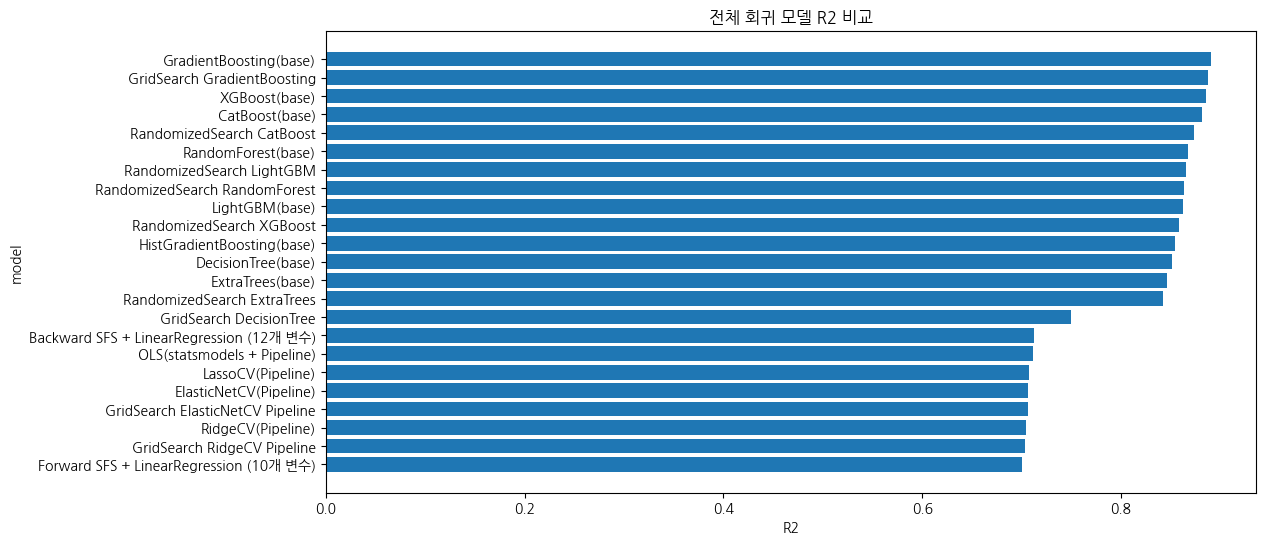

In [41]:
plt.figure(figsize=(12, 6))
plt.barh(final_scores["model"], final_scores["R2"])
plt.gca().invert_yaxis()
plt.title("전체 회귀 모델 R2 비교")
plt.xlabel("R2")
plt.ylabel("model")
plt.show()

## 15. 해석 정리

### 이번 수정 버전의 핵심
1. **8번 이후 모델은 모두 scikit-learn 중심으로 통일**했습니다.
2. **후진선택 / 전진선택**은 `SequentialFeatureSelector` + `Pipeline`으로 구현했습니다.
3. **정규화 회귀**는 `LassoCV`, `RidgeCV`, `ElasticNetCV`로 비교했습니다.
4. **GridSearchCV / RandomizedSearchCV**를 추가해 튜닝 결과까지 함께 비교하도록 구성했습니다.
5. **트리 계열도 scikit-learn 모델만 사용**하도록 정리했습니다.

### 수업에서 강조하면 좋은 포인트
- `Pipeline`을 사용하면 **스케일링 + 변수선택 + 모델학습** 흐름을 한 번에 관리할 수 있습니다.
- `LassoCV`, `RidgeCV`, `ElasticNetCV`는 **규제 강도(alpha)를 자동 탐색**합니다.
- `GridSearchCV`는 **정해진 후보를 촘촘히 탐색**하고, `RandomizedSearchCV`는 **넓은 범위를 빠르게 탐색**할 때 유용합니다.
- 선형계열은 해석이 좋고, 트리계열은 비선형 관계를 더 잘 잡을 수 있어 **예측 성능 비교 수업**에 적합합니다.
